# Trimester 2 End-of-Term Project
## Building a Production-Ready Credit Risk Classification System
### Notebook 1: EDA, Preprocessing & Feature Engineering

Name: Mohammed Rashiku B C

Student ID: iitp_aiml_25061023

In [1]:
# SECTION 2 — Environment Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)


In [2]:
# SECTION 3 — Mount Drive & Folder Structure
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/T2_Project_Mohammed_Rashiku_BC/"

Mounted at /content/drive


In [3]:
# SECTION 4 — Load Dataset
df = pd.read_csv("/content/drive/MyDrive/T2_Project_Mohammed_Rashiku_BC/Data/german_credit_data.csv")
df.head()


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,56,male,1,own,little,moderate,6745,22,car,good
1,69,female,2,free,moderate,moderate,10437,70,car,good
2,46,male,3,own,quite rich,little,9763,8,car,good
3,32,female,1,own,moderate,little,18964,70,radio/TV,bad
4,60,male,2,own,moderate,little,17650,14,domestic appliances,good


In [4]:
# SECTION 5 — Basic Exploration

df.shape
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   915 non-null    object
 5   Checking account  905 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


np.int64(0)

# SECTION 5 — Basic Exploration

## Dataset Shape

The dataset contains **1000 rows and 10 columns**.

- Each row represents one individual applicant.
- Each column represents a feature describing the applicant.

---

## Dataset Information (`df.info()`)

- Total entries: **1000**
- Total columns: **10**
- Data types:
  - **4 numerical (int64)** → Age, Job, Credit amount, Duration
  - **6 categorical (object)** → Sex, Housing, Saving accounts, Checking account, Purpose, Risk

## Missing Values (`df.isnull().sum()`)

Missing values are present in:

- **Saving accounts** → 915 non-null (85 missing values)
- **Checking account** → 905 non-null (95 missing values)

All other columns contain complete data (1000 non-null values).

These missing values should be handled during preprocessing by:
- Filling with the most frequent category
- Replacing with a new category such as "Unknown"
- Applying suitable imputation methods

## Duplicate Records (`df.duplicated().sum()`)

Number of duplicate rows: **0**

## Target Distribution (`Risk`)

The target variable is **Risk**, which represents credit risk classification:

- **Good**
- **Bad**

The dataset is moderately imbalanced:
- Approximately **70% Good**
- Approximately **30% Bad**

Implications:
- The dataset is not perfectly balanced.
- Evaluation metrics such as **precision, recall, and F1-score** should be considered instead of relying only on accuracy.
- Techniques like class weighting or resampling (e.g., SMOTE) may improve model performance.

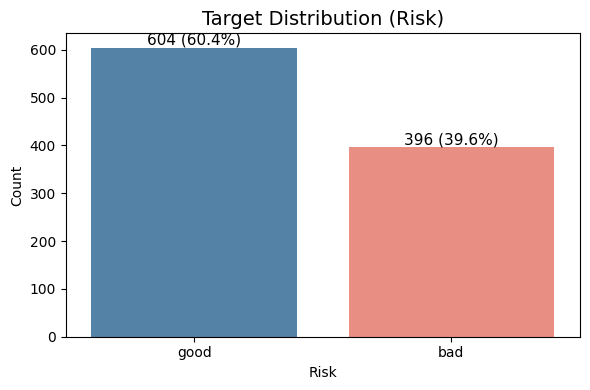

✅ Saved: target_distribution.png


,proportion
Risk,
good,0.604
bad,0.396


In [6]:
# SECTION 6 — Target Distribution

import os
os.makedirs(base_path + 'Visualizations', exist_ok=True)

plt.figure(figsize=(6,4))
ax = sns.countplot(x='Risk', data=df, palette=['steelblue','salmon'])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)',
                (p.get_x()+p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.title('Target Distribution (Risk)', fontsize=14)
plt.xlabel('Risk')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(base_path + 'Visualizations/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: target_distribution.png')

df['Risk'].value_counts(normalize=True)

## Target Distribution (Risk)

The normalized distribution of the target variable **Risk** is:

- **Good** → 60.4%
- **Bad** → 39.6%

### Interpretation

- The dataset is **moderately imbalanced**.
- The majority class is **Good (60.4%)**.
- The minority class is **Bad (39.6%)**.

### What This Means for Modeling

- The imbalance is not extreme, but it is noticeable.
- Accuracy alone may be misleading.
- Evaluation metrics such as:
  - Precision
  - Recall
  - F1-score
  - ROC-AUC

  should be considered.

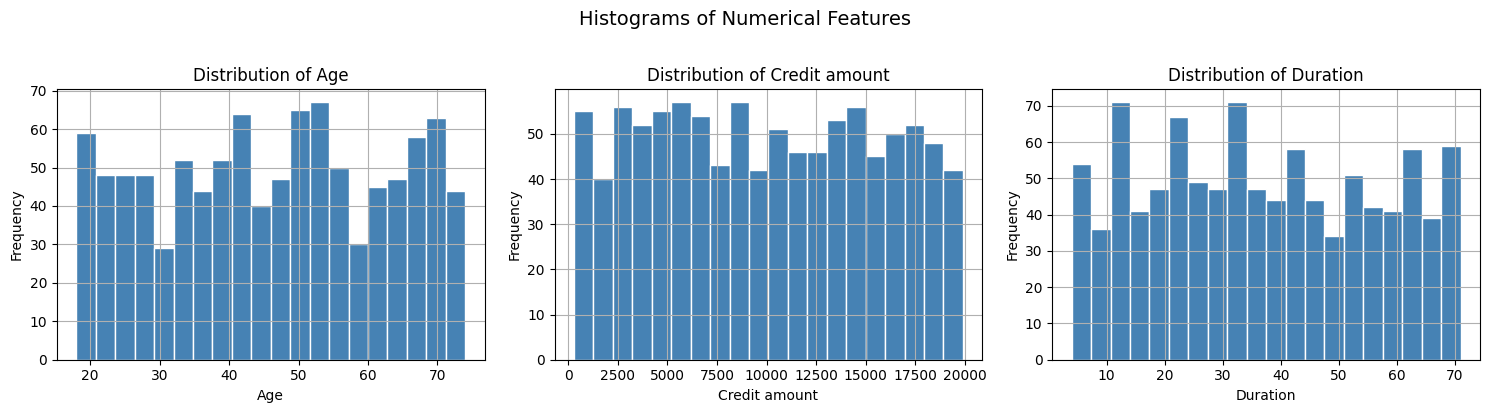

✅ Saved: histograms_numerical.png


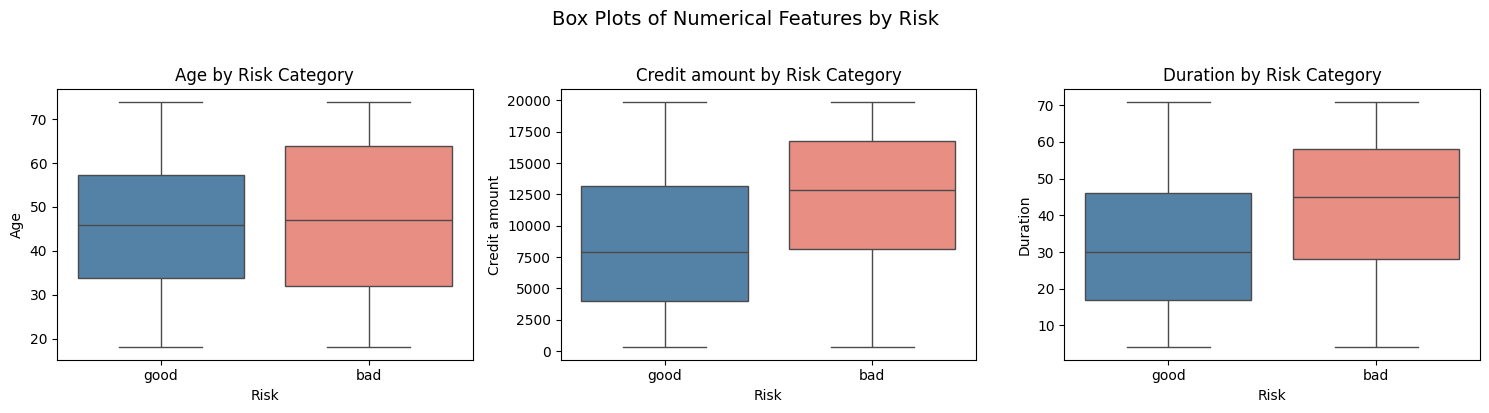

✅ Saved: boxplots_by_risk.png


In [7]:
# SECTION 7 — Numerical Feature Analysis

num_cols = ['Age', 'Credit amount', 'Duration']

# Histograms
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(num_cols):
    df[col].hist(ax=axes[i], bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.suptitle('Histograms of Numerical Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(base_path + 'Visualizations/histograms_numerical.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: histograms_numerical.png')

# Box plots by Risk
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(num_cols):
    sns.boxplot(x='Risk', y=col, data=df, ax=axes[i], palette=['steelblue','salmon'])
    axes[i].set_title(f'{col} by Risk Category', fontsize=12)
plt.suptitle('Box Plots of Numerical Features by Risk', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(base_path + 'Visualizations/boxplots_by_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: boxplots_by_risk.png')



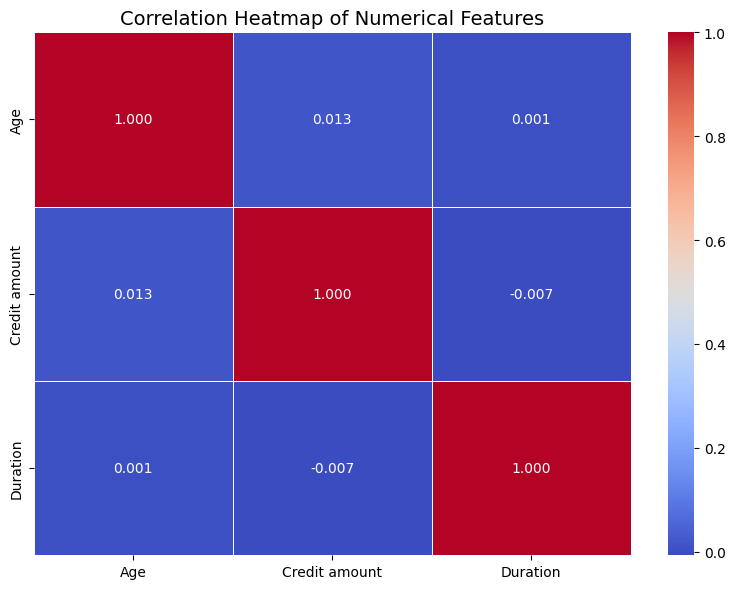

✅ Saved: correlation_heatmap.png


In [9]:
# SECTION 8 — Correlation Heatmap

plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.tight_layout()
plt.savefig(base_path + 'Visualizations/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: correlation_heatmap.png')

## Interpretation

- All correlation values are very close to **0**.
- This indicates **no strong linear relationships** between the numerical features.
- There is **no multicollinearity concern** among these variables.
- All numerical features can be safely used in modeling without removing any due to correlation.

## Conclusion

The numerical variables in this dataset are largely independent of one another.  
This is beneficial for many machine learning algorithms, especially linear models, as it reduces the risk of redundancy and multicollinearity.

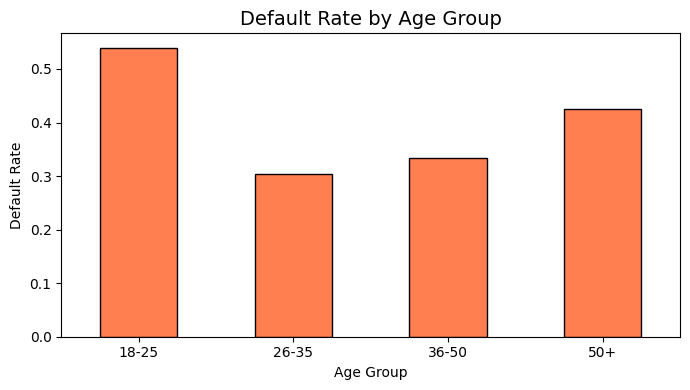

✅ Saved: default_rate_by_age.png


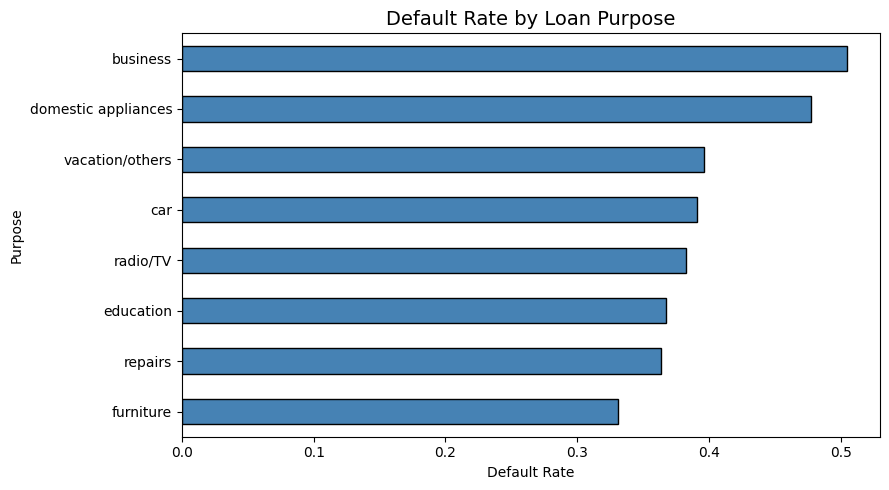

✅ Saved: default_rate_by_purpose.png


In [10]:
# SECTION 9 — 2 Advanced Insightful Plots

# Plot 1: Default Rate by Age Group
df['Age_Group'] = pd.cut(df['Age'],
                          bins=[17, 25, 35, 50, 100],
                          labels=['18-25', '26-35', '36-50', '50+'])

age_default = df.groupby('Age_Group', observed=True)['Risk'].apply(
    lambda x: (x == 'bad').mean() if x.dtype == object else x.mean()
)

plt.figure(figsize=(7, 4))
age_default.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Default Rate by Age Group', fontsize=14)
plt.ylabel('Default Rate')
plt.xlabel('Age Group')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(base_path + 'Visualizations/default_rate_by_age.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: default_rate_by_age.png')

# Plot 2: Default Rate by Loan Purpose
purpose_default = df.groupby('Purpose')['Risk'].apply(
    lambda x: (x == 'bad').mean() if x.dtype == object else x.mean()
).sort_values()

plt.figure(figsize=(9, 5))
purpose_default.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Default Rate by Loan Purpose', fontsize=14)
plt.xlabel('Default Rate')
plt.tight_layout()
plt.savefig(base_path + 'Visualizations/default_rate_by_purpose.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: default_rate_by_purpose.png')


# Default Rate by Age Group
## Observed Pattern:

18–25 -> Highest default rate (~56%)

26–35 -> Lowest (~30%)

# Business Insight:

Age is clearly a strong predictive feature.
This variable should definitely be included in any scoring model.

# Default Rate by Loan Purpose

## Highest Risk Purposes:

Business (~50%)

Domestic appliances (~48%)

# Interpretation:

Business loans are highest risk

In [11]:
# SECTION 10 — Missing Value Strategy

print('Missing values BEFORE imputation:')
print(df[['Saving accounts', 'Checking account']].isnull().sum())

df['Saving accounts'] = df['Saving accounts'].fillna('unknown')
df['Checking account'] = df['Checking account'].fillna('unknown')

print('\nMissing values AFTER imputation:')
print(df[['Saving accounts', 'Checking account']].isnull().sum())

print('\nValue counts — Saving accounts:')
print(df['Saving accounts'].value_counts())

print('\nValue counts — Checking account:')
print(df['Checking account'].value_counts())


Missing values BEFORE imputation:
Saving accounts     85
Checking account    95
dtype: int64

Missing values AFTER imputation:
Saving accounts     0
Checking account    0
dtype: int64

Value counts — Saving accounts:
Saving accounts
little        412
moderate      303
rich          117
unknown        85
quite rich     83
Name: count, dtype: int64

Value counts — Checking account:
Checking account
little      505
moderate    265
rich        135
unknown      95
Name: count, dtype: int64


## Missing Value Strategy — Rationale

Missing values in **Saving accounts** and **Checking account** were filled with `"unknown"` instead of using statistical imputation.

This approach is appropriate because missing financial account information may carry meaningful risk signals (e.g., underbanked or thin-file customers). Replacing missing values with the most frequent category could distort this signal and introduce bias.

By assigning `"unknown"` as a separate category, we:
- Preserve potential predictive information  
- Avoid incorrect assumptions about customer similarity  
- Maintain categorical consistency for modeling  

This strategy aligns with standard credit risk modeling practices, where missingness is often treated as a distinct risk segment.

In [12]:
# SECTION 11 — Feature Engineering (4 Strong Features)

# Feature 1: Credit_to_Duration_Ratio
# Higher monthly obligation relative to loan size → higher risk
df['Credit_to_Duration'] = df['Credit amount'] / df['Duration']

# Feature 2: Account_Stability_Score
# Combined ordinal score of savings + checking account strength
# NOTE: Used as a NUMERIC feature only — NOT re-encoded via OHE
account_map = {'unknown': 0, 'little': 1, 'moderate': 2, 'rich': 3, 'quite rich': 4}
df['Account_Stability'] = (
    df['Saving accounts'].map(account_map) +
    df['Checking account'].map(account_map)
)

# Feature 3: High_Credit_Flag
# Binary flag: credit amount above median is a risk indicator
df['High_Credit'] = (df['Credit amount'] > df['Credit amount'].median()).astype(int)

# Feature 4: Long_Duration_Flag
# Binary flag: longer loans carry higher default exposure
df['Long_Duration'] = (df['Duration'] > df['Duration'].median()).astype(int)

print('✅ Feature Engineering Complete!')
print('New features preview:')
print(df[['Credit_to_Duration', 'Account_Stability', 'High_Credit', 'Long_Duration']].describe())

✅ Feature Engineering Complete!
New features preview:
       Credit_to_Duration  Account_Stability  High_Credit  Long_Duration
count         1000.000000        1000.000000   1000.00000    1000.000000
mean           443.559034           3.141000      0.50000       0.486000
std            578.392562           1.323961      0.50025       0.500054
min              4.197183           0.000000      0.00000       0.000000
25%            134.455357           2.000000      0.00000       0.000000
50%            263.827586           3.000000      0.50000       0.000000
75%            497.363889           4.000000      1.00000       1.000000
max           4765.500000           7.000000      1.00000       1.000000


## Feature Engineering — Justification

| Feature | Type | Rationale |
|---|---|---|
| `Credit_to_Duration` | Continuous | Monthly debt burden proxy. High values indicate large loans in short windows — a strong default signal. |
| `Account_Stability` | Ordinal Score | Combines savings and checking account strength into one score (0–8). Lower scores strongly correlate with higher default risk. |
| `High_Credit` | Binary | Loans above the median amount introduce a step-change in risk exposure; binary flag captures this threshold effect. |
| `Long_Duration` | Binary | Longer-tenure loans accumulate more uncertainty and payment stress. This flag captures loans beyond the median duration. |

> **Note:** `Account_Stability` is computed as a numeric composite score **before** One-Hot Encoding so the ordinal account columns are not double-represented in the final feature matrix.

In [13]:
# SECTION 12 — Encode Target

df['Risk'] = df['Risk'].map({'good': 0, 'bad': 1})

print('Target encoding complete:')
print(df['Risk'].value_counts().rename({0: 'good (0)', 1: 'bad (1)'}))
print(f'\nClass balance: {df["Risk"].mean()*100:.1f}% bad (minority class)')


Target encoding complete:
Risk
good (0)    604
bad (1)     396
Name: count, dtype: int64

Class balance: 39.6% bad (minority class)


In [14]:
# SECTION 13 — Train-Test Split (Stratified)

X = df.drop('Risk', axis=1)
y = df['Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train set: {X_train.shape[0]} rows | Test set: {X_test.shape[0]} rows')
print(f'\ny_train class distribution:')
print(y_train.value_counts().rename({0:'good', 1:'bad'}))
print(f'\ny_test class distribution:')
print(y_test.value_counts().rename({0:'good', 1:'bad'}))


Train set: 800 rows | Test set: 200 rows

y_train class distribution:
Risk
good    483
bad     317
Name: count, dtype: int64

y_test class distribution:
Risk
good    121
bad      79
Name: count, dtype: int64


## SECTION 14 — Encoding & Scaling

### Encoding
All remaining categorical features (`Sex`, `Housing`, `Saving accounts`, `Checking account`, `Purpose`, `Age_Group`) are converted using **One-Hot Encoding** with `drop_first=True` to avoid the dummy variable trap.  
The test set is **aligned to training columns** via `reindex` to handle any unseen category values.

### Scaling
Continuous numerical features are standardized using **StandardScaler** (zero mean, unit variance) as required by the preprocessing pipeline.

**Important design note for Notebook 2:**
> Since data arrives **pre-scaled** from this notebook, the Logistic Regression model in Notebook 2 should use a `Pipeline` **without** a `StandardScaler` step — or use `StandardScaler` only on the raw features if re-loading from CSV.  
> Tree-based models (Decision Tree, Random Forest, XGBoost) are **scale-invariant** and require no scaling regardless.

**Scaler is fitted on `X_train` only** — then applied (transform only) to `X_test` to prevent data leakage.

In [15]:
# SECTION 14 — Encoding & Scaling

from sklearn.preprocessing import StandardScaler

# ── Step 1: One-Hot Encode all categorical columns ────────────────────────────
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns to encode:", categorical_cols)

X_train_enc = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_enc  = pd.get_dummies(X_test,  columns=categorical_cols, drop_first=True)

# Align test set columns to match train set exactly (handles unseen categories)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# Convert bool → int (compatibility with sklearn/XGBoost)
X_train_enc = X_train_enc.astype({c: int for c in X_train_enc.select_dtypes('bool').columns})
X_test_enc  = X_test_enc.astype({c: int for c in X_test_enc.select_dtypes('bool').columns})

print(f"\nAfter encoding — X_train shape: {X_train_enc.shape}")
print(f"After encoding — X_test  shape: {X_test_enc.shape}")

# ── Step 2: Identify columns to scale ─────────────────────────────────────────
# Binary/indicator columns (0/1 only) should NOT be scaled — they lose meaning
binary_cols     = [c for c in X_train_enc.columns if X_train_enc[c].nunique() <= 2]
continuous_cols = [c for c in X_train_enc.columns if c not in binary_cols]

print(f"\nColumns to scale ({len(continuous_cols)}): {continuous_cols}")
print(f"Binary columns kept as-is ({len(binary_cols)}): {binary_cols}")

# ── Step 3: StandardScaler — fit on train, transform both ─────────────────────
scaler = StandardScaler()
X_train_enc[continuous_cols] = scaler.fit_transform(X_train_enc[continuous_cols])
X_test_enc[continuous_cols]  = scaler.transform(X_test_enc[continuous_cols])

print(f"\n✅ Scaling complete.")
print(f"Sample scaled values (X_train, first 3 rows, continuous cols only):")
print(X_train_enc[continuous_cols].head(3).round(4))
print(f"\nFinal X_train shape : {X_train_enc.shape}")
print(f"Final X_test  shape : {X_test_enc.shape}")


Categorical columns to encode: ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose', 'Age_Group']

After encoding — X_train shape: (800, 28)
After encoding — X_test  shape: (200, 28)

Columns to scale (6): ['Age', 'Job', 'Credit amount', 'Duration', 'Credit_to_Duration', 'Account_Stability']
Binary columns kept as-is (22): ['High_Credit', 'Long_Duration', 'Sex_male', 'Housing_own', 'Housing_rent', 'Saving accounts_moderate', 'Saving accounts_quite rich', 'Saving accounts_rich', 'Saving accounts_unknown', 'Checking account_moderate', 'Checking account_rich', 'Checking account_unknown', 'Purpose_car', 'Purpose_domestic appliances', 'Purpose_education', 'Purpose_furniture', 'Purpose_radio/TV', 'Purpose_repairs', 'Purpose_vacation/others', 'Age_Group_26-35', 'Age_Group_36-50', 'Age_Group_50+']

✅ Scaling complete.
Sample scaled values (X_train, first 3 rows, continuous cols only):
        Age     Job  Credit amount  Duration  Credit_to_Duration  \
83   0.8943  0.7852        

## Processed Data — What Gets Saved

| File | Description |
|---|---|
| `X_train.csv` | Encoded + scaled training features (800 rows) |
| `X_test.csv` | Encoded + scaled test features (200 rows) |
| `y_train.csv` | Training labels (0 = good, 1 = bad) |
| `y_test.csv` | Test labels (0 = good, 1 = bad) |

**Note for Notebook 2:** Since data is already scaled, the Logistic Regression `Pipeline` should use data directly without adding another `StandardScaler`. All other models (Decision Tree, Random Forest, XGBoost) are scale-invariant and unaffected.

In [16]:
# SECTION 14 — Save All Processed Datasets to Google Drive
import os
os.makedirs(base_path + 'Data', exist_ok=True)

X_train_enc.to_csv(base_path + 'Data/X_train.csv', index=False)
X_test_enc.to_csv( base_path + 'Data/X_test.csv',  index=False)
y_train.to_csv(    base_path + 'Data/y_train.csv', index=False, header=True)
y_test.to_csv(     base_path + 'Data/y_test.csv',  index=False, header=True)

print("✅ Saved to Google Drive:")
print(f"  {base_path}Data/X_train.csv  → shape: {X_train_enc.shape}")
print(f"  {base_path}Data/X_test.csv   → shape: {X_test_enc.shape}")
print(f"  {base_path}Data/y_train.csv  → {len(y_train)} rows")
print(f"  {base_path}Data/y_test.csv   → {len(y_test)} rows")
print()
print("ℹ  Data is encoded + scaled (StandardScaler, fit on train only).")
print("ℹ  In Notebook 2, use X_train/X_test directly — no re-scaling needed.")
print()
print("✅ Notebook 1 — EDA & Preprocessing COMPLETE")

✅ Saved to Google Drive:
  /content/drive/MyDrive/T2_Project_Mohammed_Rashiku_BC/Data/X_train.csv  → shape: (800, 28)
  /content/drive/MyDrive/T2_Project_Mohammed_Rashiku_BC/Data/X_test.csv   → shape: (200, 28)
  /content/drive/MyDrive/T2_Project_Mohammed_Rashiku_BC/Data/y_train.csv  → 800 rows
  /content/drive/MyDrive/T2_Project_Mohammed_Rashiku_BC/Data/y_test.csv   → 200 rows

ℹ  Data is encoded + scaled (StandardScaler, fit on train only).
ℹ  In Notebook 2, use X_train/X_test directly — no re-scaling needed.

✅ Notebook 1 — EDA & Preprocessing COMPLETE
